In [1]:
!pip install timm torchmetrics albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.2 MB/s eta 0:00:00


Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : resnet101
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Parameters   : 42,516,552

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3459
  Val   Loss : 0.3131
  Macro AUC  : 0.7234
  Macro mAP  : 0.3935
  Macro F1   : 0.2488
  ✓ Best model saved  (AUC = 0.7234)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


...

  Train Loss : 0.2620
  Val   Loss : 0.2993
  Macro AUC  : 0.8125
  Macro mAP  : 0.5219
  Macro F1   : 0.4041

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.2511
  Val   Loss : 0.2884
  Macro AUC  : 0.8202
  Macro mAP  : 0.5396
  Macro F1   : 0.4754

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.2406
  Val   Loss : 0.2882
  Macro AUC  : 0.8263
  Macro mAP  : 0.5383
  Macro F1   : 0.4815
  ✓ Best model saved  (AUC = 0.8263)

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.2313
  Val   Loss : 0.2888
  Macro AUC  : 0.8279
  Macro mAP  : 0.5415
  Macro F1   : 0.4869
  ✓ Best model saved  (AUC = 0.8279)

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.2253
  Val   Loss : 0.2834
  Macro AUC  : 0.8291
  Macro mAP  : 0.5457
  Macro F1   : 0.4887
  ✓ Best model saved  (AUC = 0.8291)

Training complete.  Best Validation AUC : 0.8291

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7331   0.5326   0.4827
Diabetes          0.7394   0.6072   0.4908
Glaucoma          0.8861   0.4812   0.4286
Cataract          0.9330   0.7673   0.7394
AMD               0.8585   0.4097   0.4444
Hypertension      0.8256   0.2246   0.2182
Myopia            0.9654   0.8410   0.8000
Others            0.6915   0.5018   0.3055


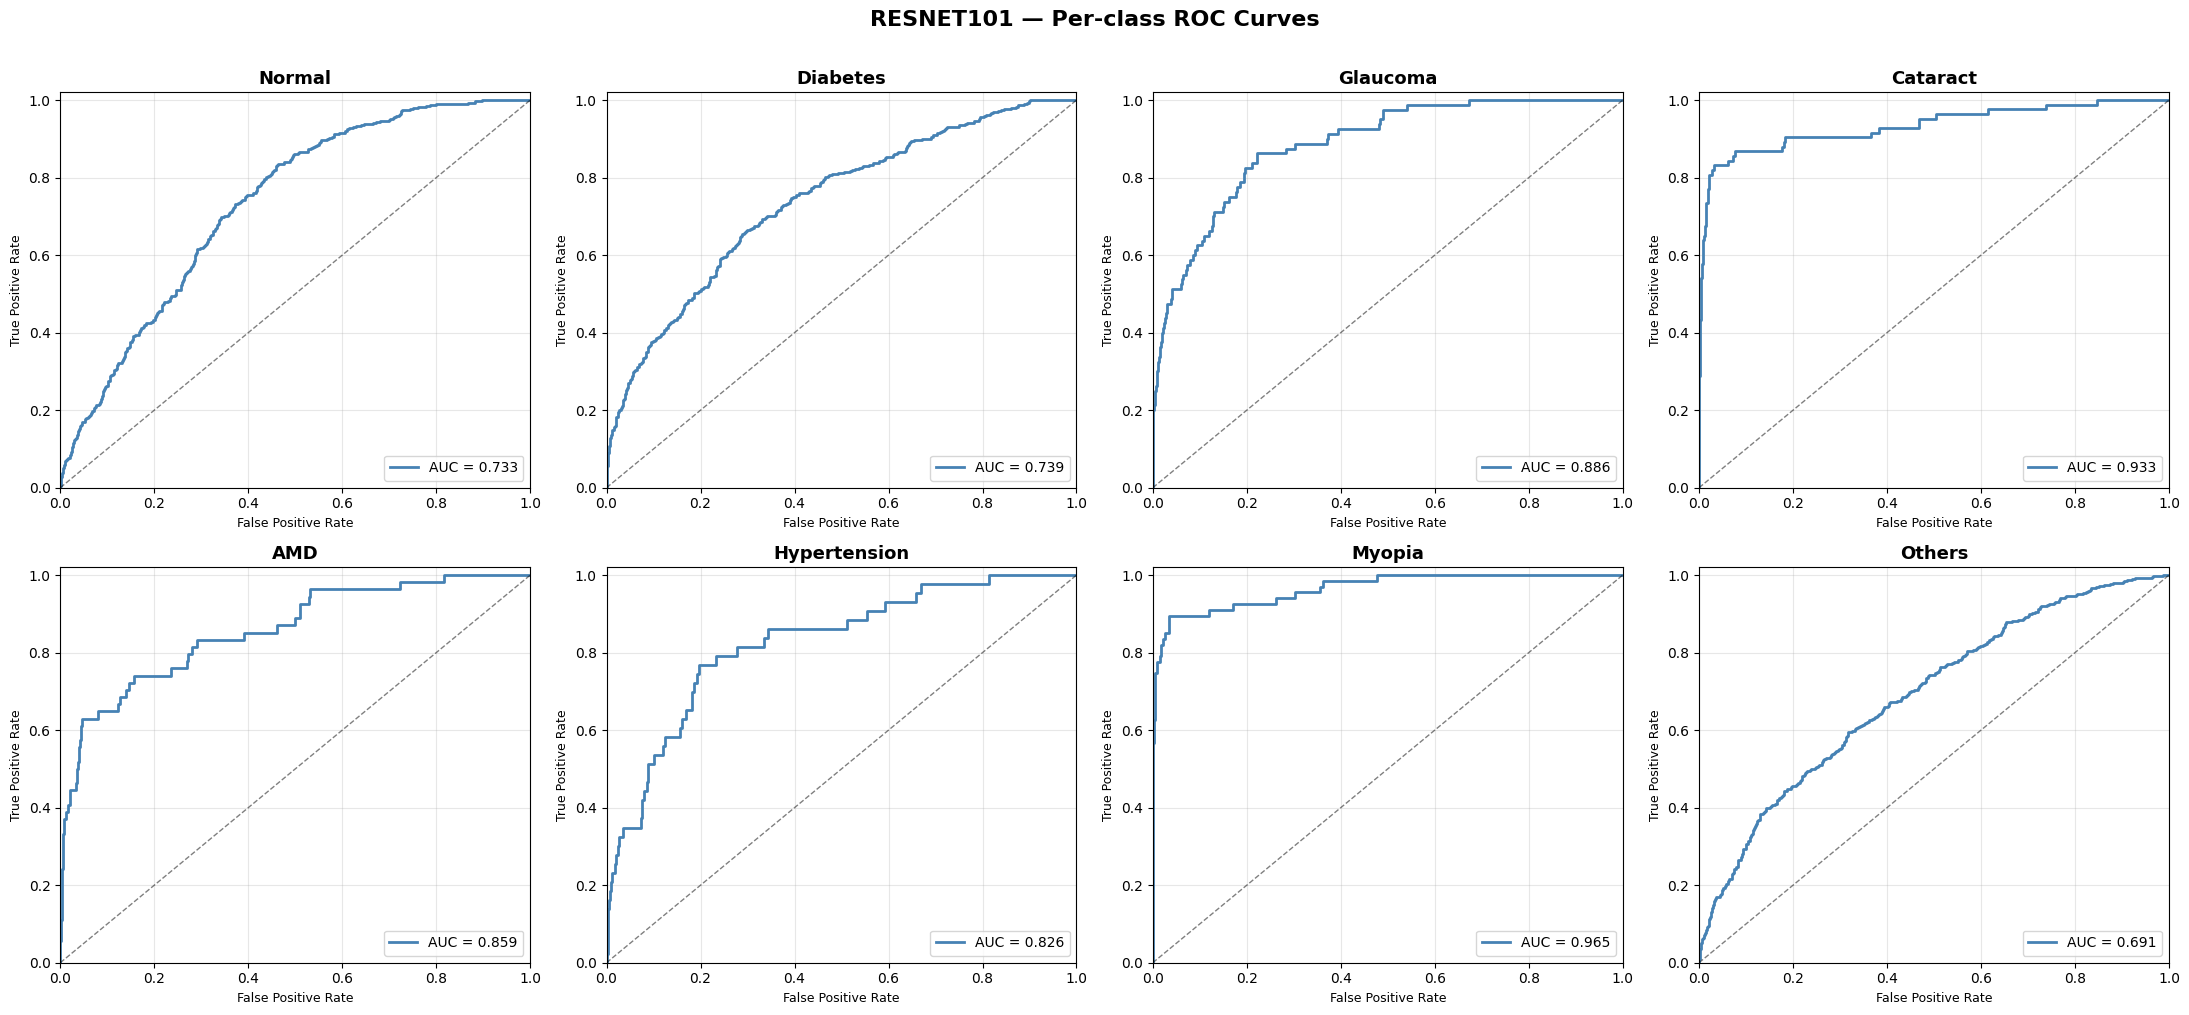

Saved: resnet101_roc_curves.png


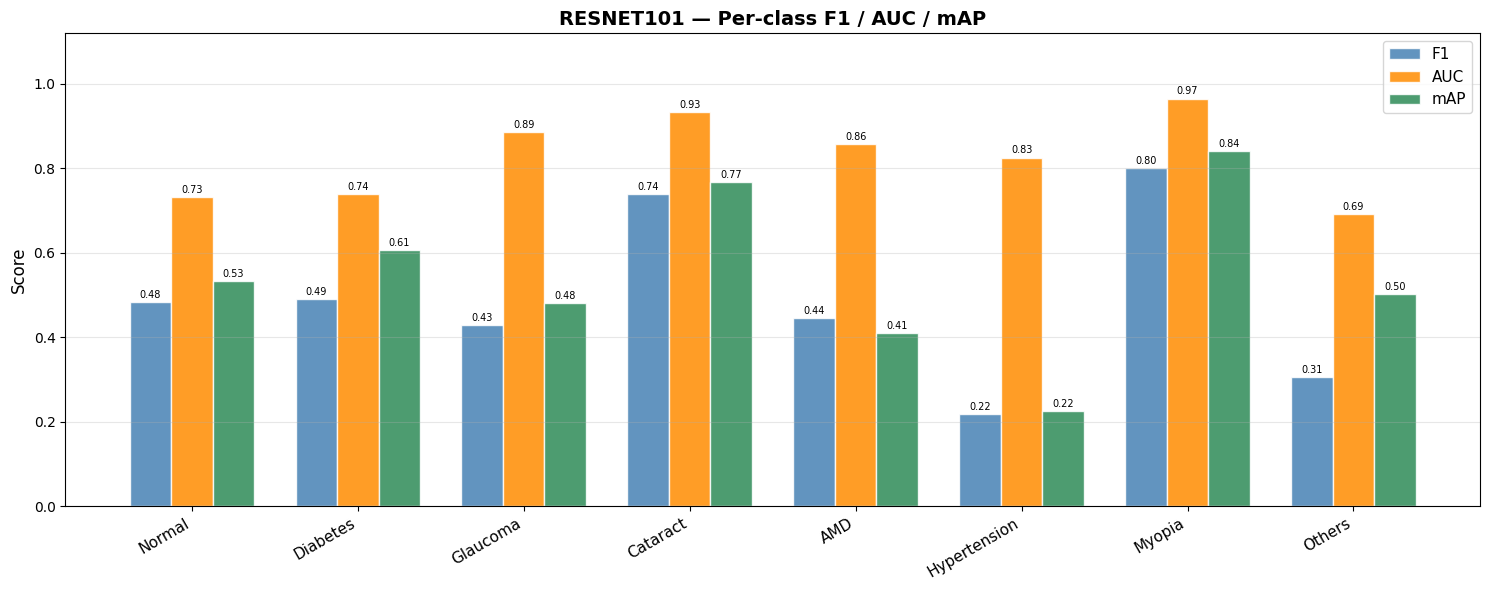

Saved: resnet101_metrics_bar.png


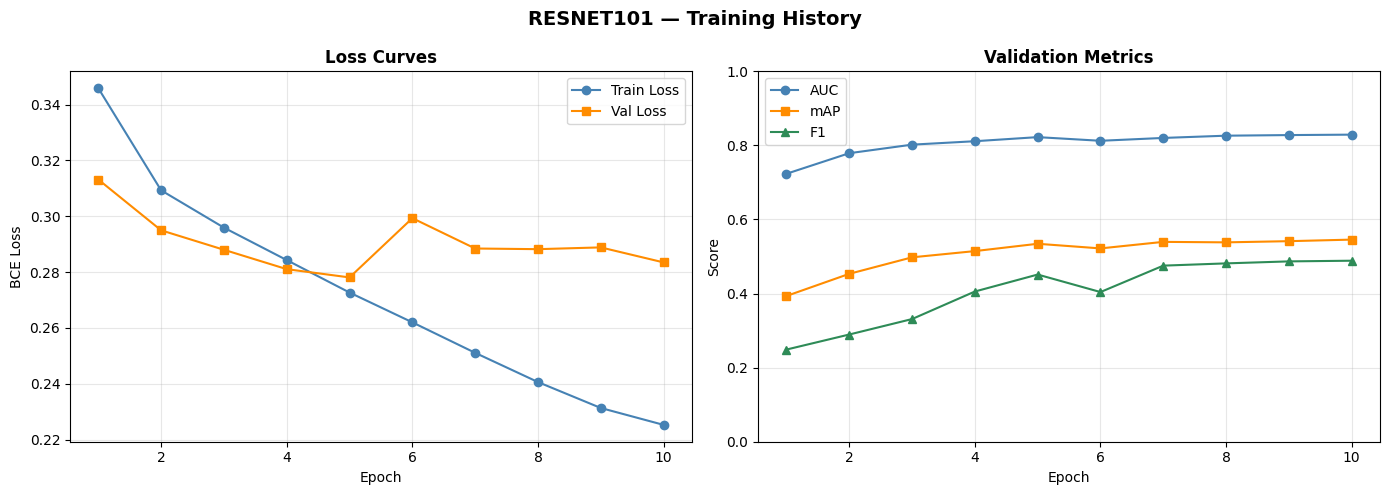

Saved: resnet101_training_curves.png
CUDA cache cleared.


In [2]:
# ============================================================
# MODEL 1: ResNet101 — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "resnet101"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
# Use A.Affine instead of deprecated ShiftScaleRotate
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="steelblue", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-", label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-", label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : densenet121
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Parameters   : 6,962,056

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3219
  Val   Loss : 0.3118
  Macro AUC  : 0.7521
  Macro mAP  : 0.4280
  Macro F1   : 0.3131
  ✓ Best model saved  (AUC = 0.7521)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.2959
  Val   Loss : 0.2868
  Macro AUC  : 0.8116
  Macro mAP  : 0.5308
  Macro F1   : 0.3696
  ✓ Best model saved  (AUC = 0.8116)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.2469
  Val   Loss : 0.2713
  Macro AUC  : 0.8339
  Macro mAP  : 0.5744
  Macro F1   : 0.5147
  ✓ Best model saved  (AUC = 0.8339)

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.2324
  Val   Loss : 0.2689
  Macro AUC  : 0.8444
  Macro mAP  : 0.5819
  Macro F1   : 0.5215
  ✓ Best model saved  (AUC = 0.8444)

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.2149
  Val   Loss : 0.2685
  Macro AUC  : 0.8396
  Macro mAP  : 0.5943
  Macro F1   : 0.5402

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.2006
  Val   Loss : 0.2694
  Macro AUC  : 0.8394
  Macro mAP  : 0.5971
  Macro F1   : 0.5521

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.1919
  Val   Loss : 0.2693
  Macro AUC  : 0.8421
  Macro mAP  : 0.5968
  Macro F1   : 0.5661

Training complete.  Best Validation AUC : 0.8444

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7672   0.5655   0.5372
Diabetes          0.7670   0.6647   0.5233
Glaucoma          0.9134   0.5407   0.4828
Cataract          0.9374   0.7835   0.7485
AMD               0.8537   0.4806   0.4419
Hypertension      0.8479   0.2580   0.2264
Myopia            0.9719   0.8628   0.8092
Others            0.6965   0.4999   0.4031


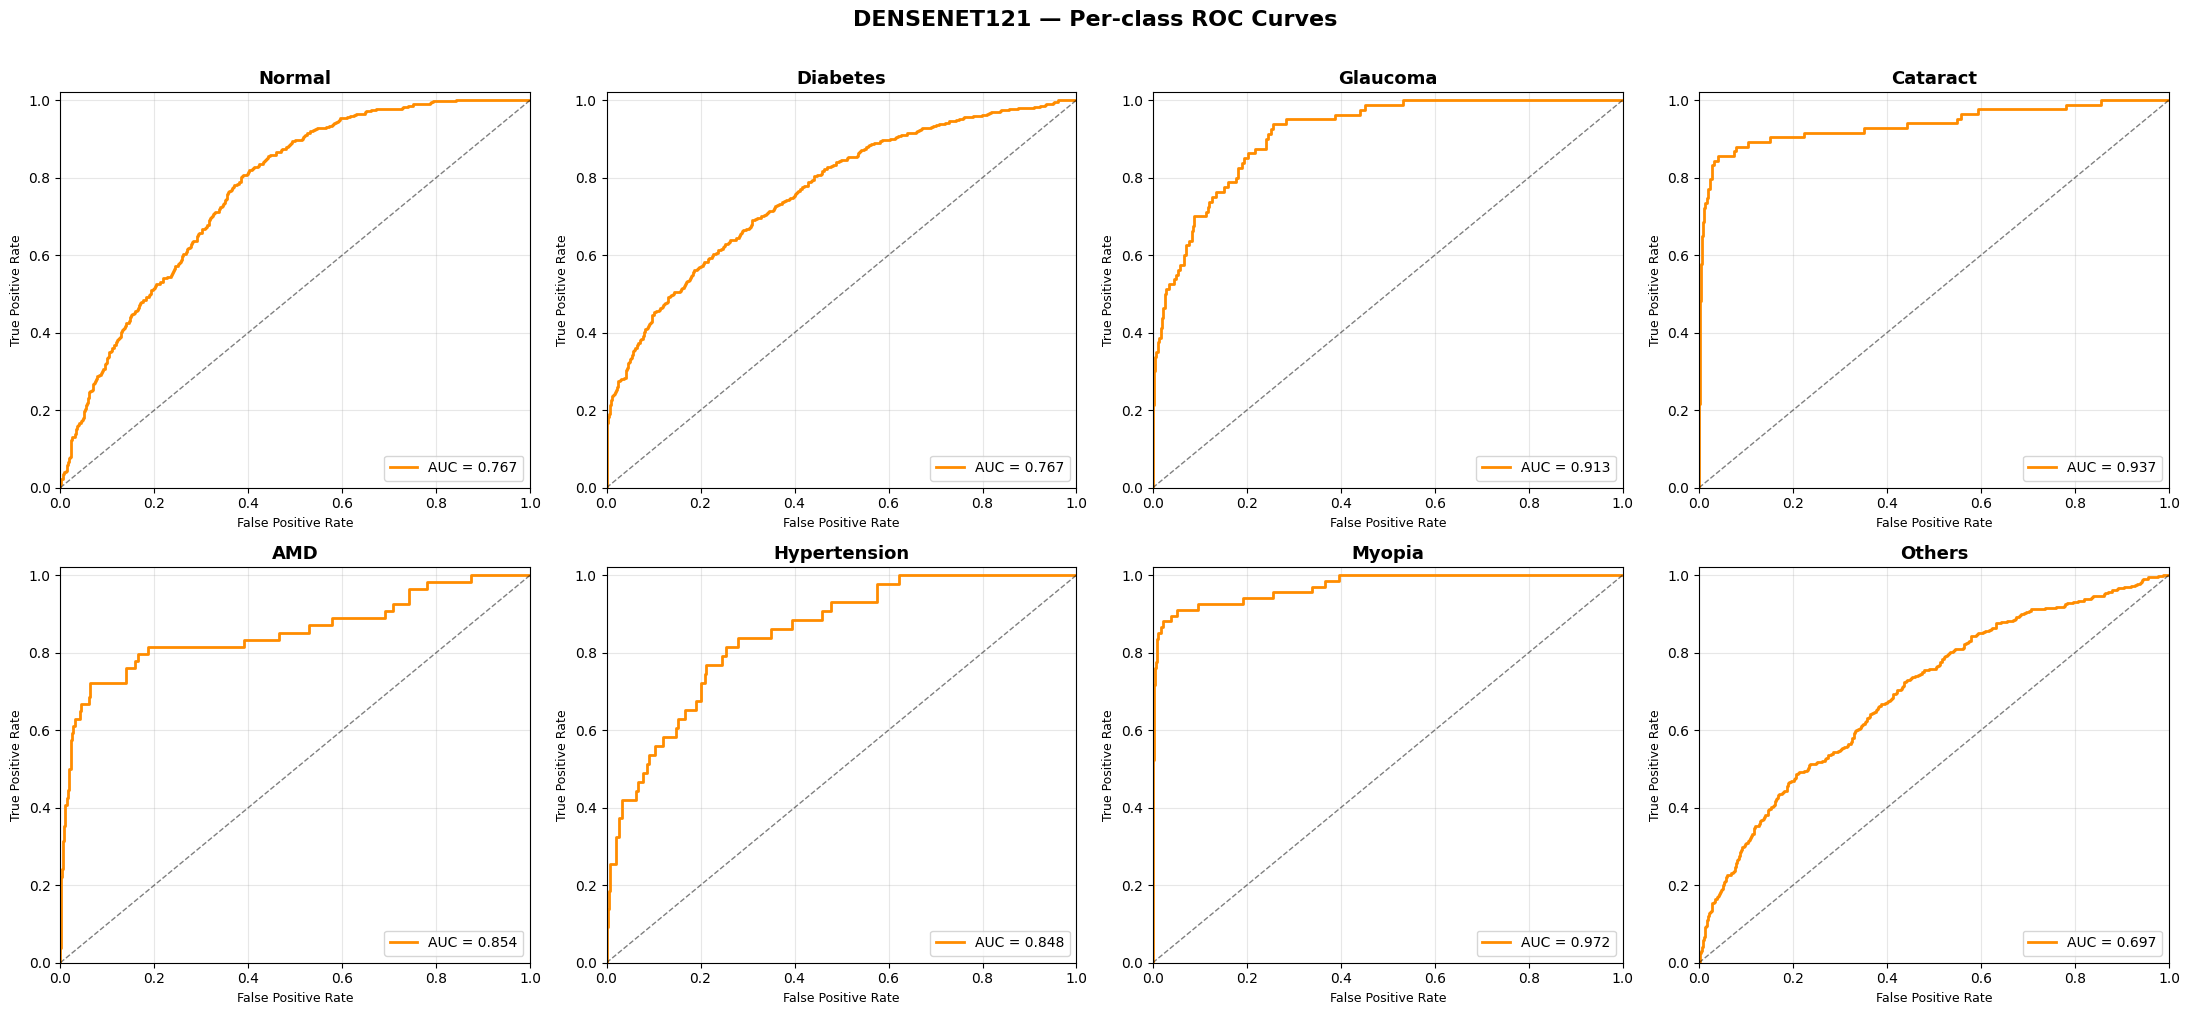

Saved: densenet121_roc_curves.png


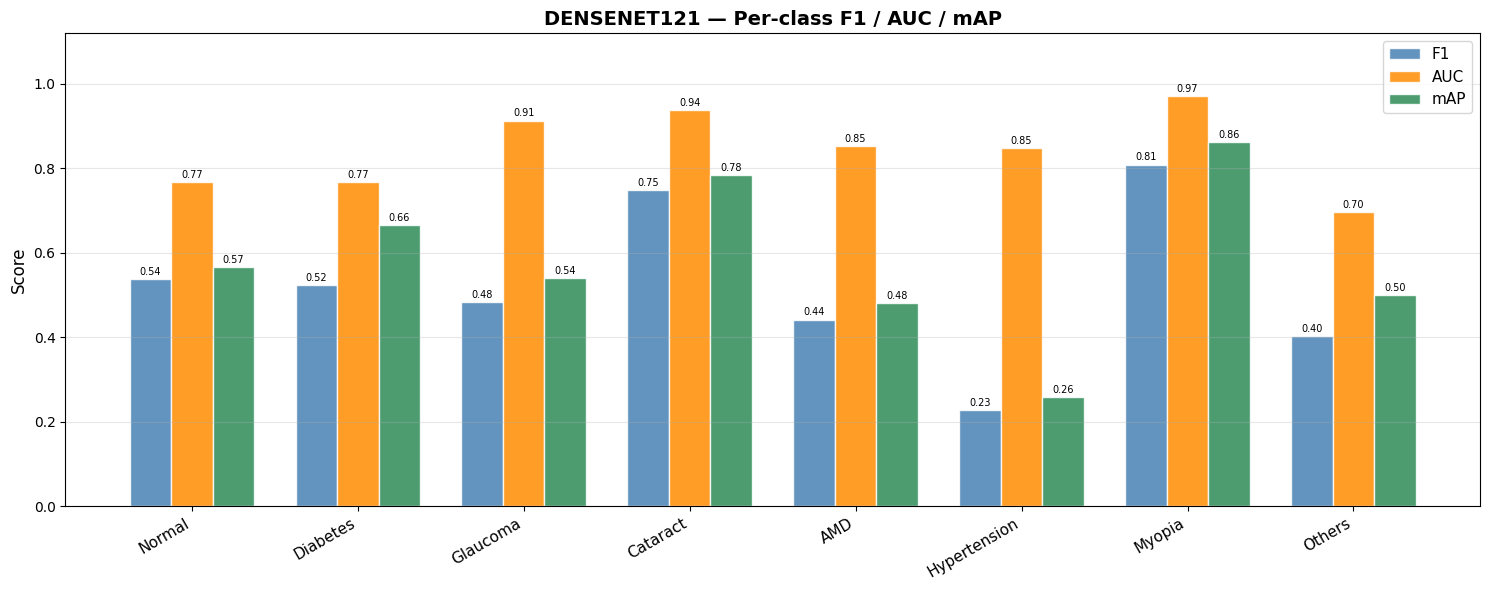

Saved: densenet121_metrics_bar.png


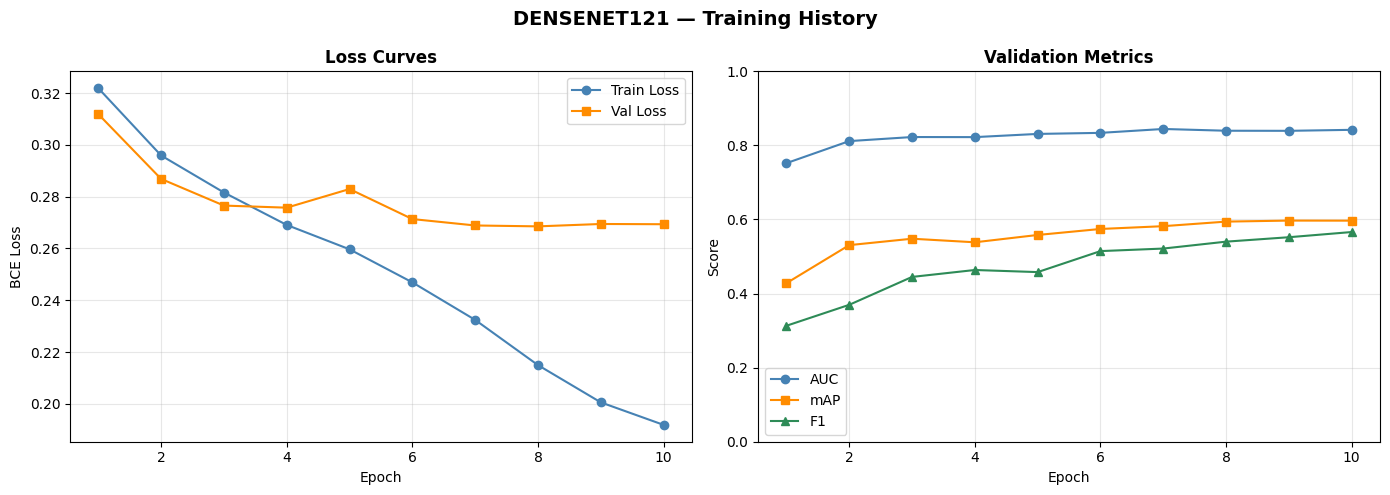

Saved: densenet121_training_curves.png
CUDA cache cleared.


In [3]:
# ============================================================
# MODEL 2: DenseNet121 — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "densenet121"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="darkorange", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : xception
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Parameters   : 20,823,344

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3229
  Val   Loss : 0.2916
  Macro AUC  : 0.7883
  Macro mAP  : 0.4946
  Macro F1   : 0.3231
  ✓ Best model saved  (AUC = 0.7883)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.2867
  Val   Loss : 0.2931
  Macro AUC  : 0.8111
  Macro mAP  : 0.5281
  Macro F1   : 0.4439
  ✓ Best model saved  (AUC = 0.8111)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.2194
  Val   Loss : 0.2724
  Macro AUC  : 0.8402
  Macro mAP  : 0.6028
  Macro F1   : 0.5461

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.1929
  Val   Loss : 0.2840
  Macro AUC  : 0.8374
  Macro mAP  : 0.5949
  Macro F1   : 0.5541

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.1632
  Val   Loss : 0.2992
  Macro AUC  : 0.8386
  Macro mAP  : 0.5996
  Macro F1   : 0.5641

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.1407
  Val   Loss : 0.3042
  Macro AUC  : 0.8390
  Macro mAP  : 0.5971
  Macro F1   : 0.5683

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.1283
  Val   Loss : 0.3034
  Macro AUC  : 0.8394
  Macro mAP  : 0.5954
  Macro F1   : 0.5774

Training complete.  Best Validation AUC : 0.8465

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7616   0.5483   0.5271
Diabetes          0.7937   0.6988   0.5444
Glaucoma          0.8852   0.4792   0.3826
Cataract          0.9440   0.7886   0.7468
AMD               0.8540   0.5507   0.5979
Hypertension      0.8651   0.2521   0.1200
Myopia            0.9714   0.8778   0.8120
Others            0.6966   0.5232   0.3546


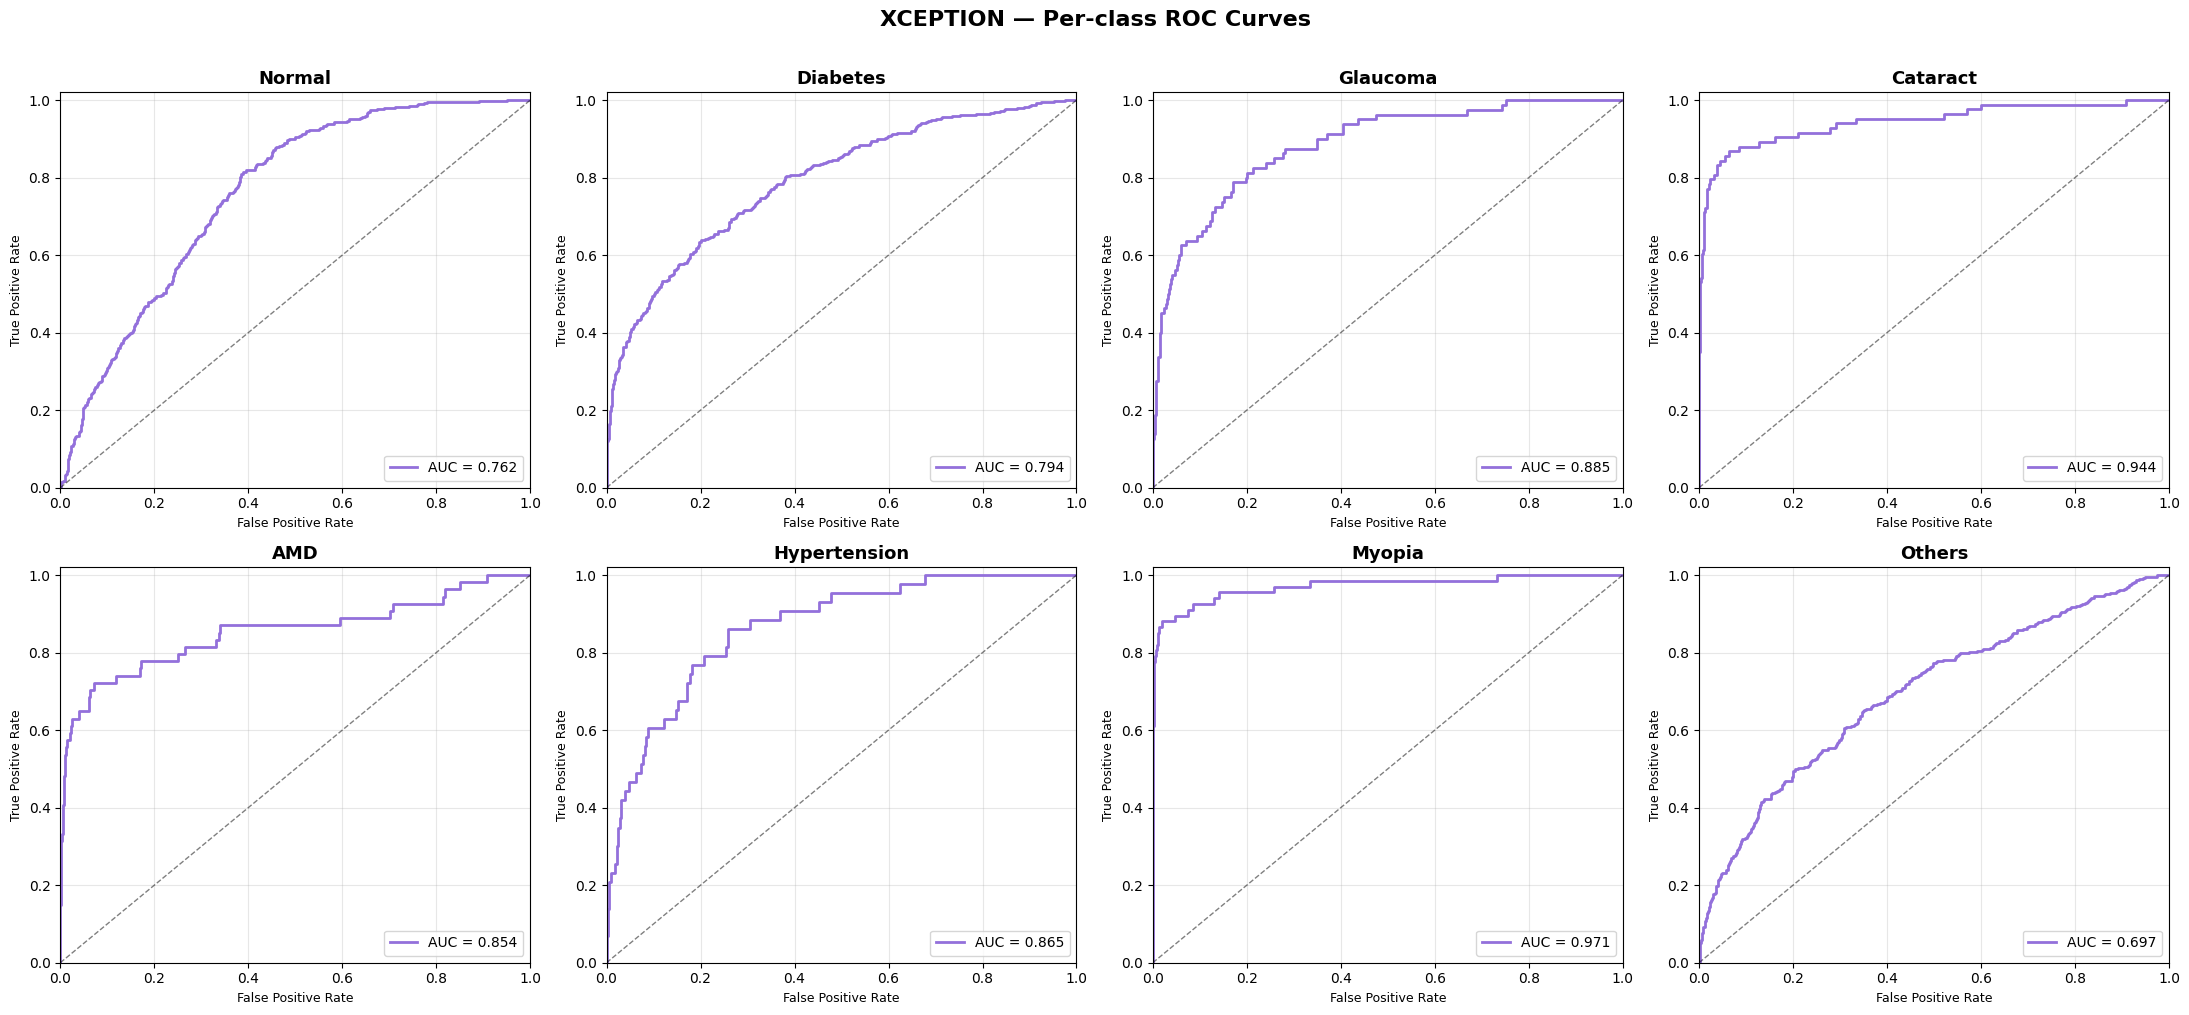

Saved: xception_roc_curves.png


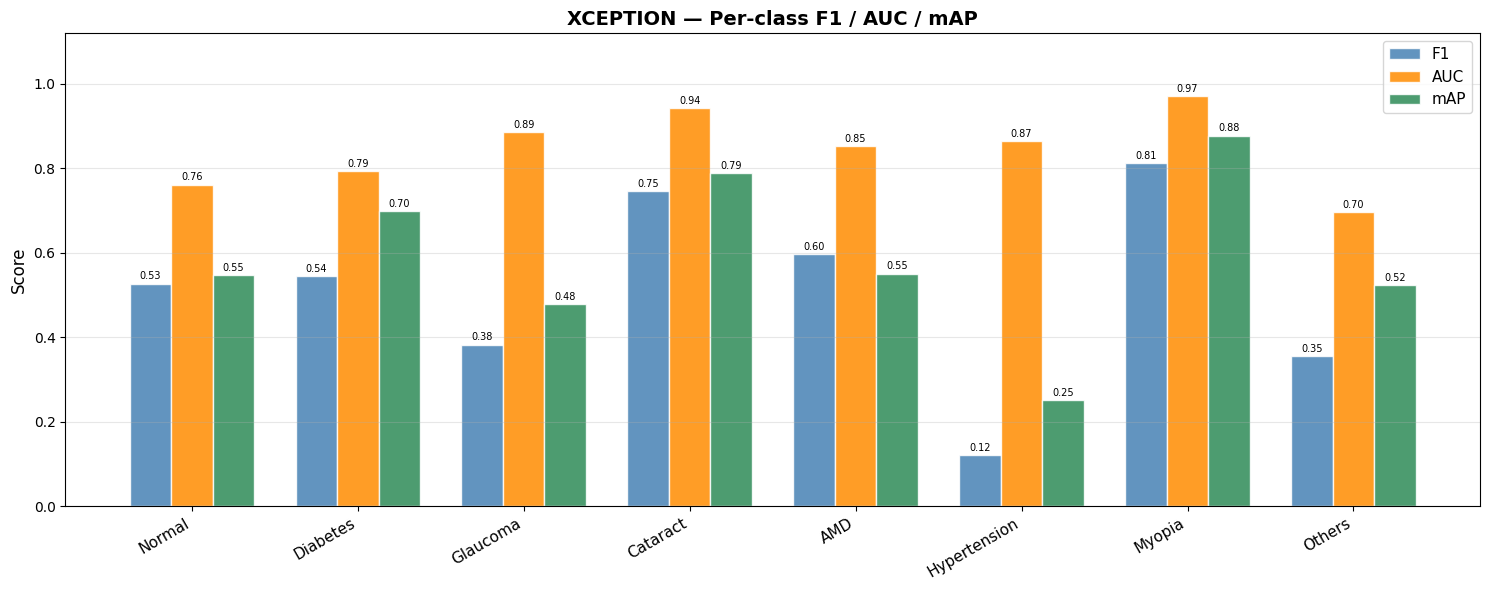

Saved: xception_metrics_bar.png


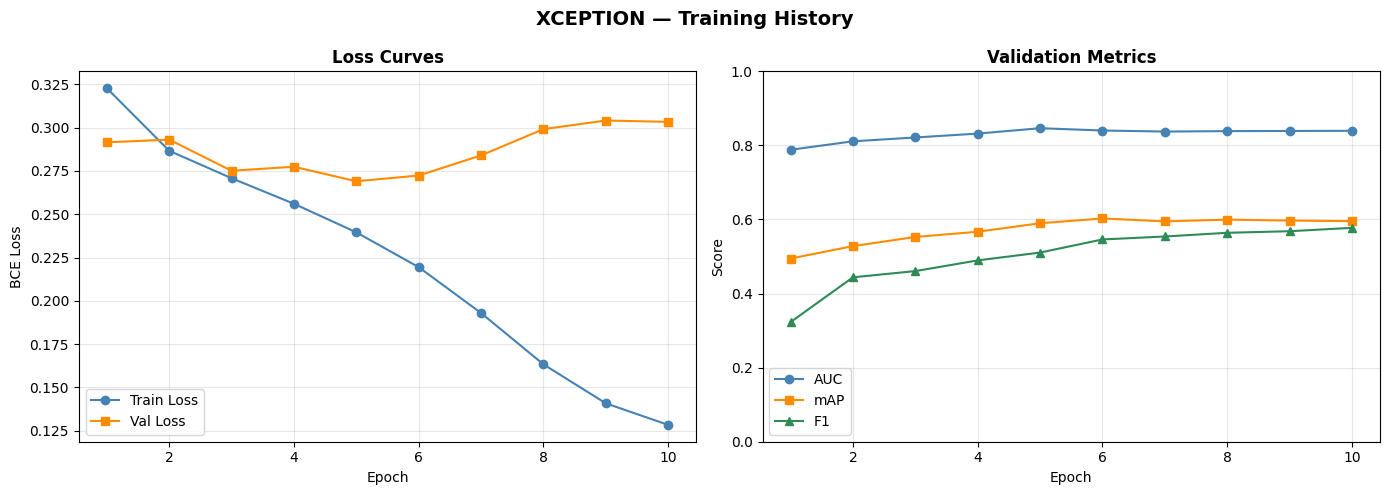

Saved: xception_training_curves.png
CUDA cache cleared.


In [5]:
# ============================================================
# MODEL 3: Xception — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "xception"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="mediumpurple", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : efficientnet_b3
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Parameters   : 10,708,528

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3449
  Val   Loss : 0.6731
  Macro AUC  : 0.7770
  Macro mAP  : 0.4518
  Macro F1   : 0.3888
  ✓ Best model saved  (AUC = 0.7770)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.2900
  Val   Loss : 0.6592
  Macro AUC  : 0.8116
  Macro mAP  : 0.5192
  Macro F1   : 0.4355
  ✓ Best model saved  (AUC = 0.8116)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.1874
  Val   Loss : 0.2986
  Macro AUC  : 0.8293
  Macro mAP  : 0.5697
  Macro F1   : 0.5241
  ✓ Best model saved  (AUC = 0.8293)

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.1494
  Val   Loss : 0.3159
  Macro AUC  : 0.8275
  Macro mAP  : 0.5728
  Macro F1   : 0.5516

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.1239
  Val   Loss : 0.3479
  Macro AUC  : 0.8314
  Macro mAP  : 0.5750
  Macro F1   : 0.5465
  ✓ Best model saved  (AUC = 0.8314)

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.1039
  Val   Loss : 0.3569
  Macro AUC  : 0.8305
  Macro mAP  : 0.5695
  Macro F1   : 0.5463

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.0929
  Val   Loss : 0.3630
  Macro AUC  : 0.8298
  Macro mAP  : 0.5727
  Macro F1   : 0.5474

Training complete.  Best Validation AUC : 0.8314

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7706   0.5732   0.5822
Diabetes          0.7755   0.6637   0.5576
Glaucoma          0.9079   0.5169   0.4463
Cataract          0.9349   0.7563   0.7485
AMD               0.8104   0.4518   0.4946
Hypertension      0.7864   0.2510   0.3103
Myopia            0.9706   0.8560   0.8120
Others            0.6945   0.5315   0.4201


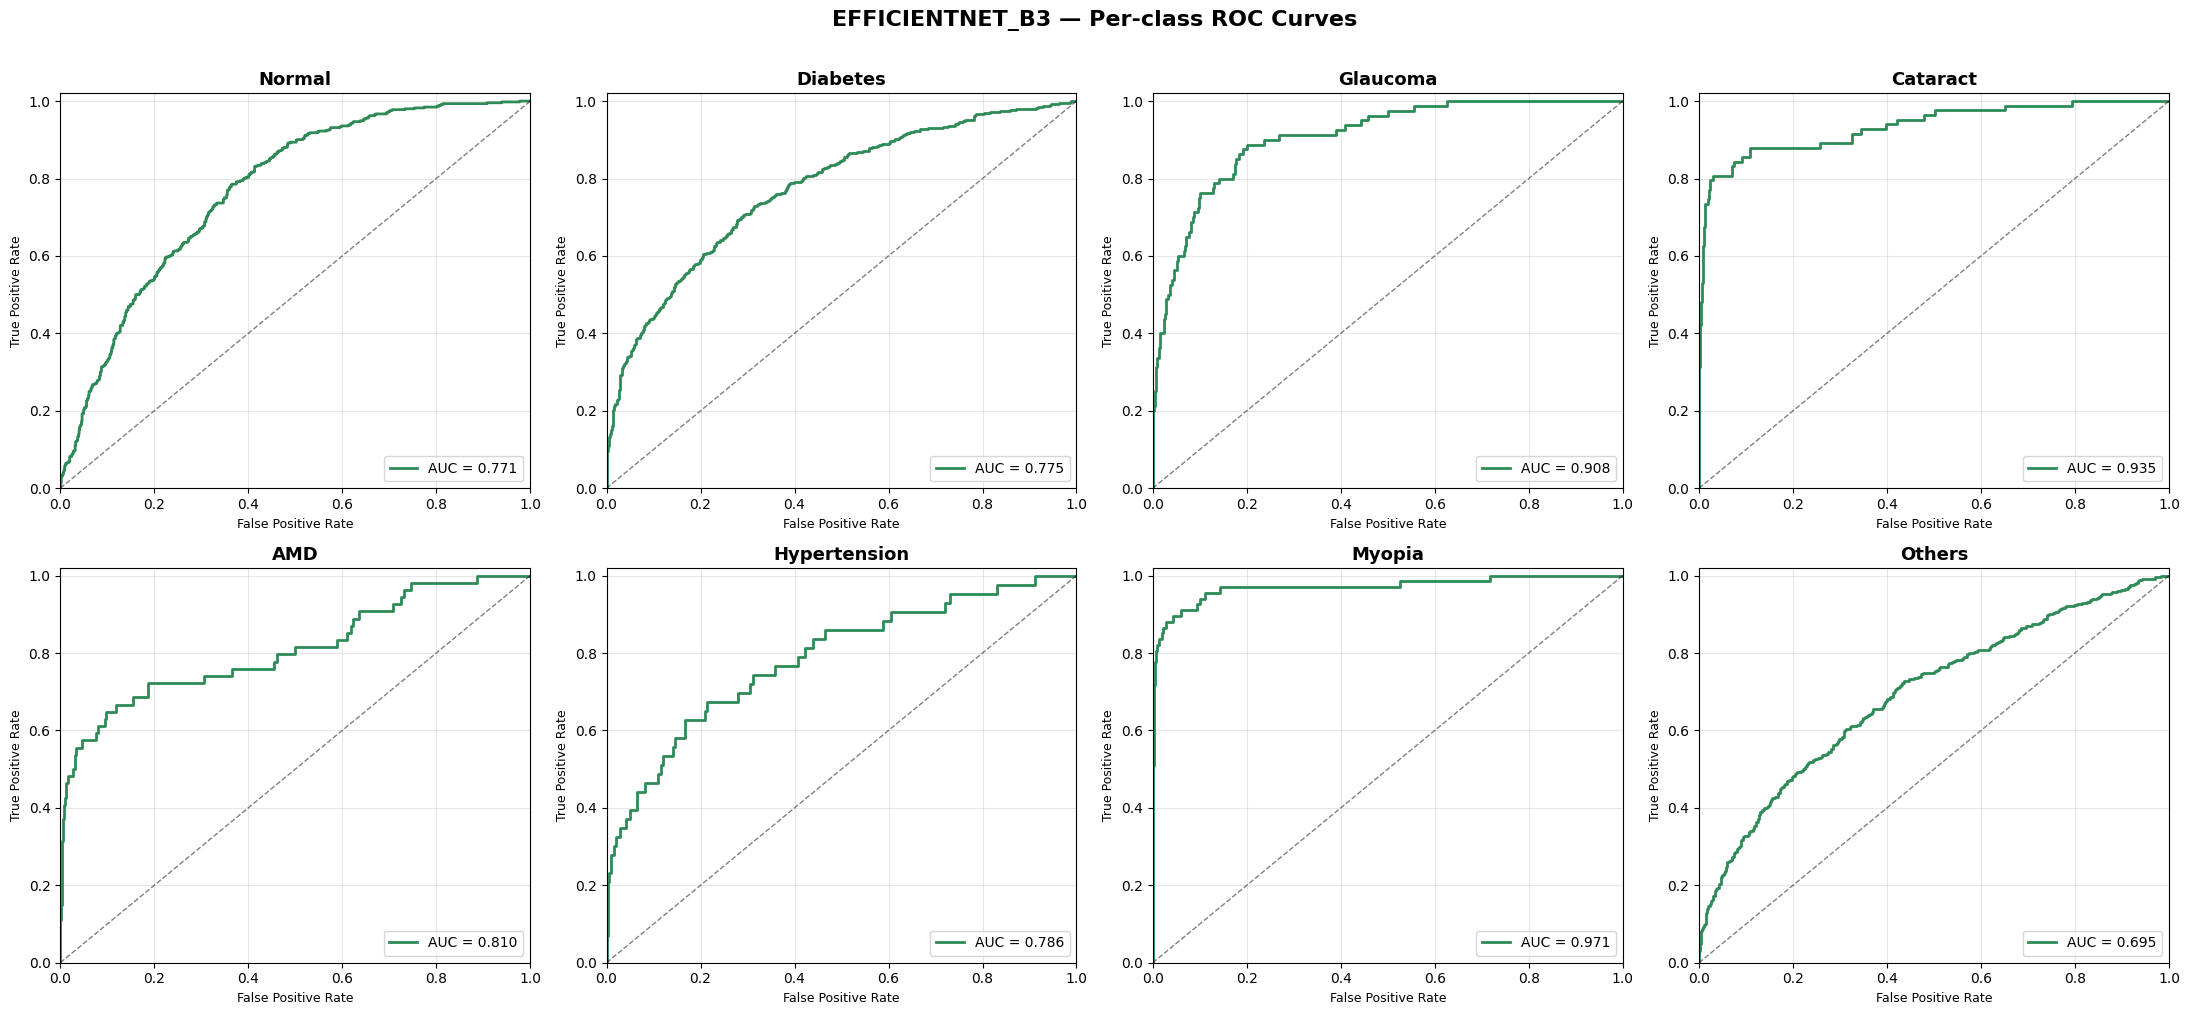

Saved: efficientnet_b3_roc_curves.png


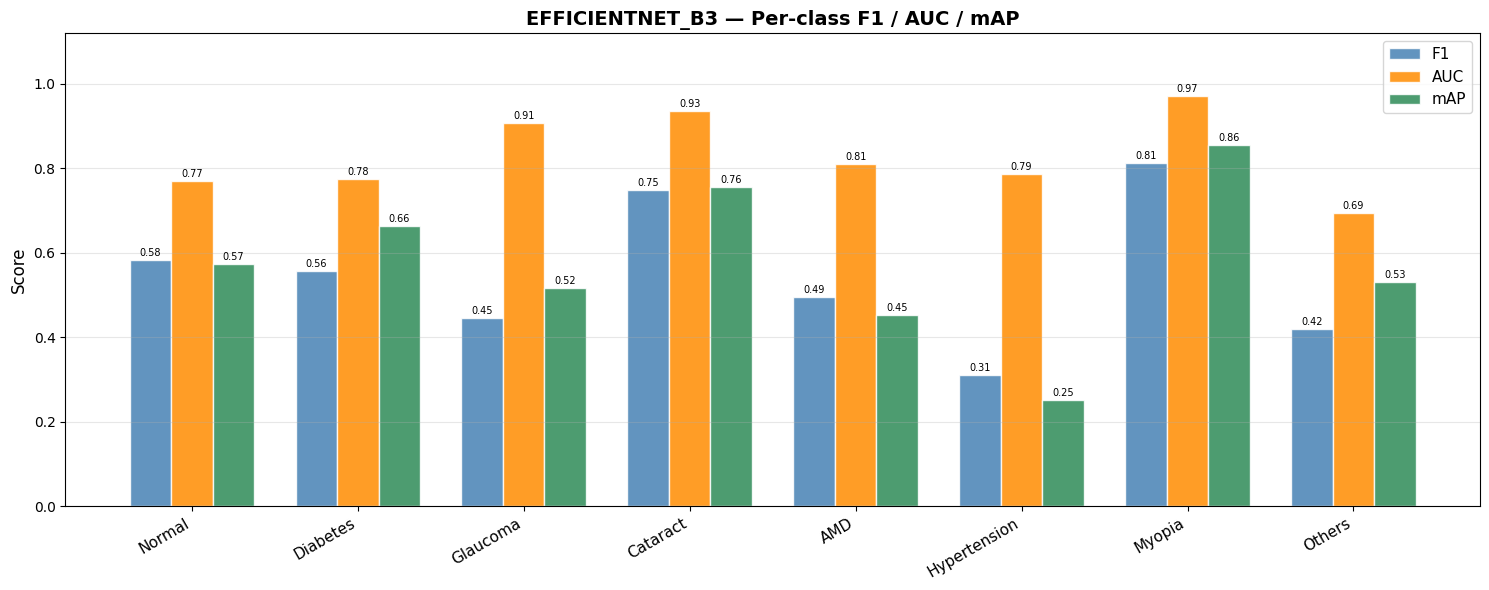

Saved: efficientnet_b3_metrics_bar.png


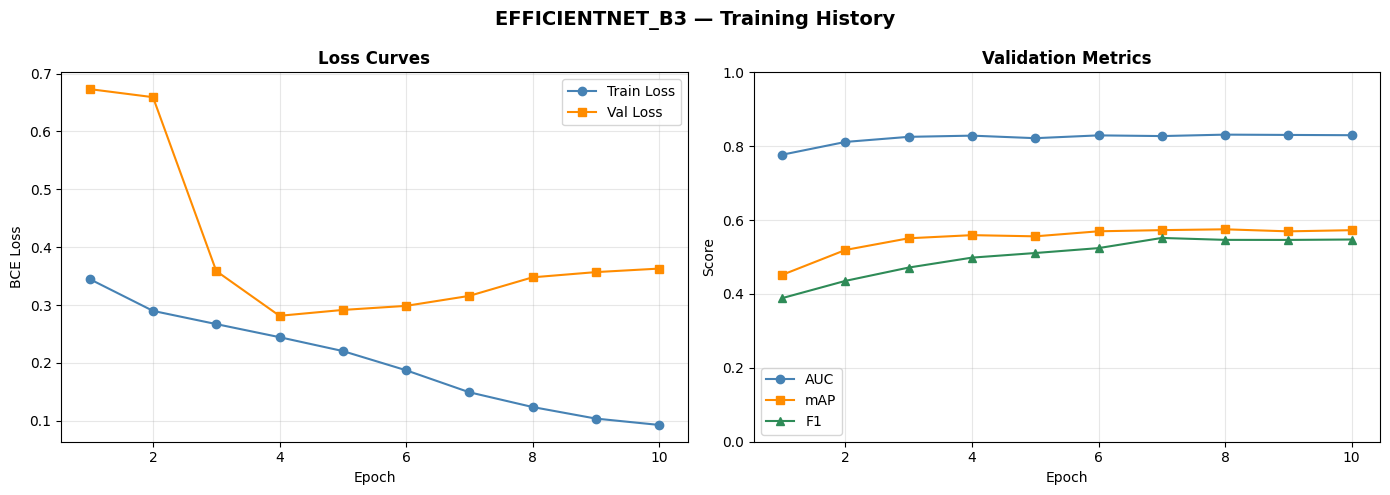

Saved: efficientnet_b3_training_curves.png
CUDA cache cleared.


In [4]:
# ============================================================
# MODEL 4: EfficientNet-B3 — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "efficientnet_b3"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="seagreen", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
Model        : convnext_base
Using Colab cache for faster access to the 'ocular-disease-recognition-odir5k' dataset.
Dataset path : /kaggle/input/ocular-disease-recognition-odir5k
Excel shape  : (3500, 15)
Columns      : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Image dir    : /kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images  (7000 images)
Left col     : Left-Fundus
Right col    : Right-Fundus
Label cols   : ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Total samples: 7000  (skipped 0 missing images)
Train        : 5600  Val: 1400


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Parameters   : 87,574,664

Epoch [01/10]  lr=3.00e-04
-------------------------------------------------------


  Train Loss : 0.3244
  Val   Loss : 0.2953
  Macro AUC  : 0.7772
  Macro mAP  : 0.4601
  Macro F1   : 0.2757
  ✓ Best model saved  (AUC = 0.7772)

Epoch [02/10]  lr=2.93e-04
-------------------------------------------------------


  Train Loss : 0.2927
  Val   Loss : 0.2847
  Macro AUC  : 0.8132
  Macro mAP  : 0.5244
  Macro F1   : 0.3322
  ✓ Best model saved  (AUC = 0.8132)

Epoch [03/10]  lr=2.71e-04
-------------------------------------------------------


...

  Train Loss : 0.2074
  Val   Loss : 0.2675
  Macro AUC  : 0.8420
  Macro mAP  : 0.6088
  Macro F1   : 0.5607
  ✓ Best model saved  (AUC = 0.8420)

Epoch [07/10]  lr=1.04e-04
-------------------------------------------------------


  Train Loss : 0.1762
  Val   Loss : 0.2816
  Macro AUC  : 0.8364
  Macro mAP  : 0.6074
  Macro F1   : 0.5536

Epoch [08/10]  lr=6.18e-05
-------------------------------------------------------


  Train Loss : 0.1376
  Val   Loss : 0.3142
  Macro AUC  : 0.8371
  Macro mAP  : 0.6206
  Macro F1   : 0.5824

Epoch [09/10]  lr=2.86e-05
-------------------------------------------------------


  Train Loss : 0.1041
  Val   Loss : 0.3230
  Macro AUC  : 0.8409
  Macro mAP  : 0.6215
  Macro F1   : 0.5820

Epoch [10/10]  lr=7.34e-06
-------------------------------------------------------


  Train Loss : 0.0864
  Val   Loss : 0.3521
  Macro AUC  : 0.8404
  Macro mAP  : 0.6211
  Macro F1   : 0.5859

Training complete.  Best Validation AUC : 0.8420

Class                AUC      mAP       F1
------------------------------------------
Normal            0.7823   0.5824   0.5424
Diabetes          0.7953   0.7034   0.5778
Glaucoma          0.9079   0.5380   0.5287
Cataract          0.9422   0.8215   0.7901
AMD               0.8669   0.5898   0.6327
Hypertension      0.7879   0.2242   0.1224
Myopia            0.9533   0.8584   0.8346
Others            0.7007   0.5528   0.4565


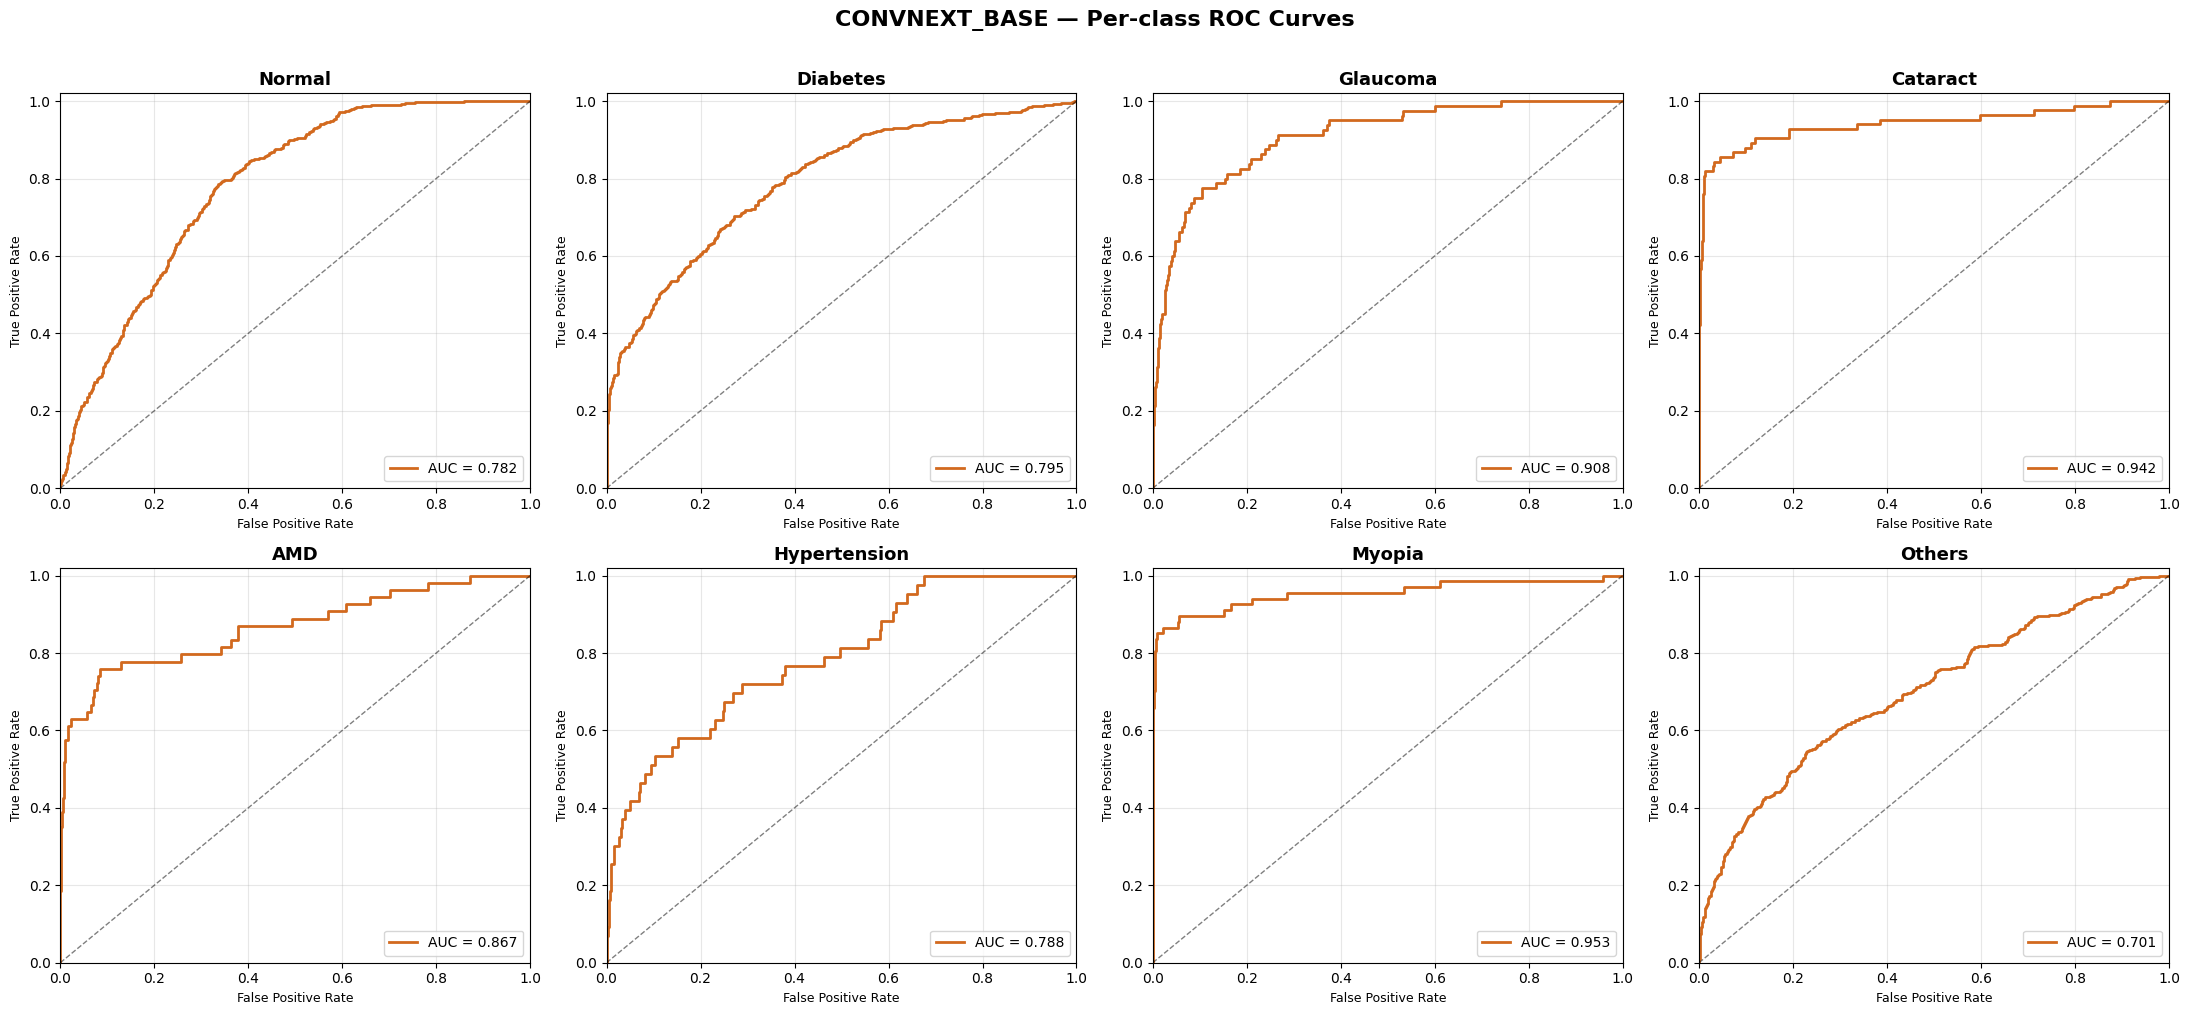

Saved: convnext_base_roc_curves.png


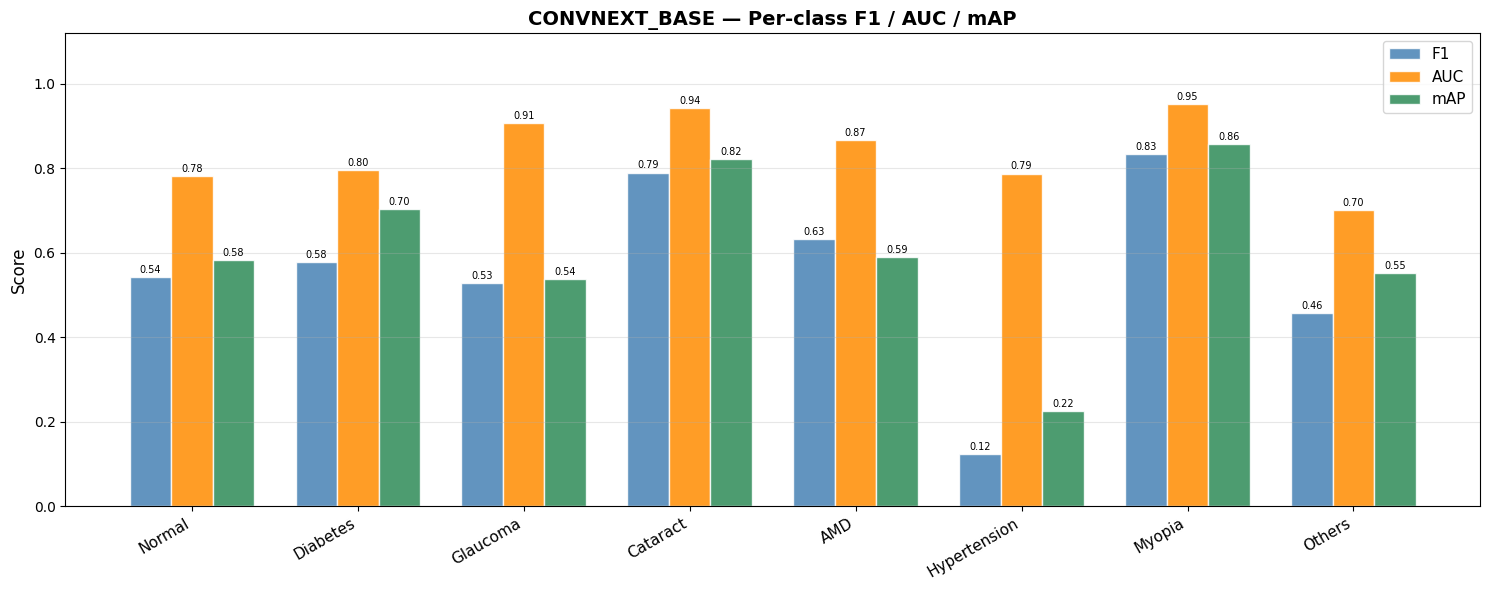

Saved: convnext_base_metrics_bar.png


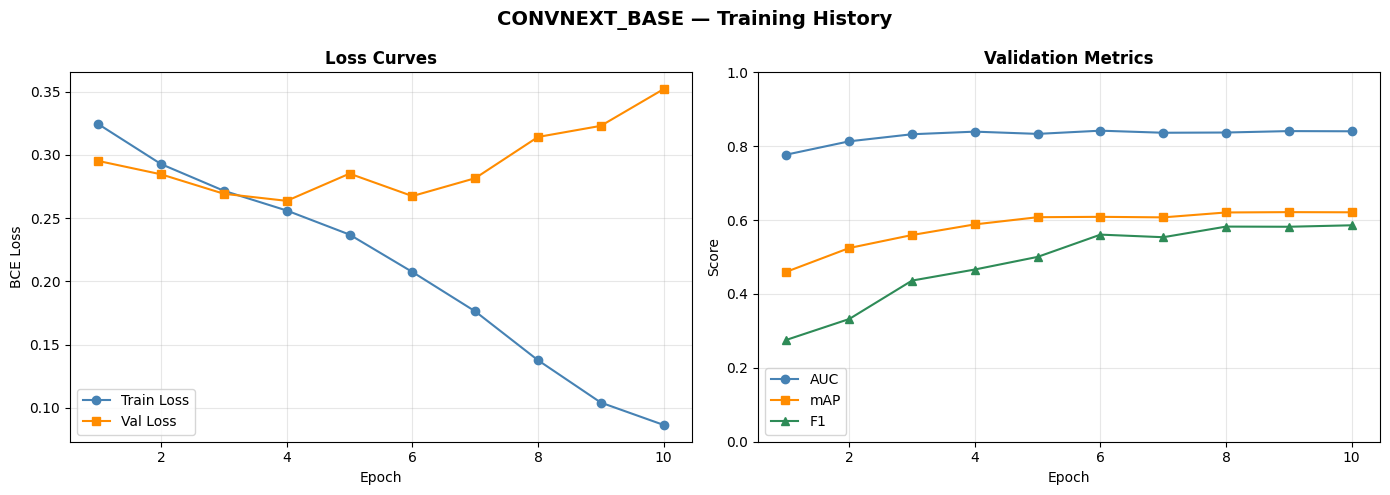

Saved: convnext_base_training_curves.png
CUDA cache cleared.


In [6]:
# ============================================================
# MODEL 5: ConvNeXt-Base — ODIR-5K Multi-Label Classification
# FIXED: Uses binary label columns directly, Affine instead of
#        ShiftScaleRotate, verified GPU usage
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
from torchmetrics.classification import (
    MultilabelAUROC, MultilabelAveragePrecision, MultilabelF1Score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Config ───────────────────────────────────────────────────
MODEL_NAME   = "convnext_base"
NUM_CLASSES  = 8
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sanity-check GPU ─────────────────────────────────────────
print(f"Using device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Enable via Runtime → Change runtime type → GPU")

print(f"Model        : {MODEL_NAME}")

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD",    "Hypertension", "Myopia", "Others"]

# Label columns already binarised in the Excel
LABEL_COLS  = ["N", "D", "G", "C", "A", "H", "M", "O"]

# ── Download Dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("andrewmvd/ocular-disease-recognition-odir5k")
print(f"Dataset path : {path}")

# ── Load Labels ──────────────────────────────────────────────
excel_candidates = glob(os.path.join(path, "**", "data.xlsx"), recursive=True)
assert len(excel_candidates) > 0, "data.xlsx not found!"
df = pd.read_excel(excel_candidates[0])
df.columns = [c.strip() for c in df.columns]
print(f"Excel shape  : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")

# ── Find image directory ──────────────────────────────────────
img_dirs = []
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 10:
        img_dirs.append((root, len(imgs)))
img_dirs.sort(key=lambda x: -x[1])
IMAGE_DIR = img_dirs[0][0]
print(f"Image dir    : {IMAGE_DIR}  ({img_dirs[0][1]} images)")

# ── Helper: resolve image path ───────────────────────────────
def resolve_path(fname):
    """Return full path for a filename, searching recursively if needed."""
    direct = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(direct):
        return direct
    matches = glob(os.path.join(path, "**", fname), recursive=True)
    return matches[0] if matches else None

# ── Build per-eye sample list using binary label columns ──────
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

left_fname_col  = find_col(df, ["Left-Fundus",  "Left Fundus",  "left_fundus"])
right_fname_col = find_col(df, ["Right-Fundus", "Right Fundus", "right_fundus"])
assert left_fname_col  is not None, "Left-Fundus column not found"
assert right_fname_col is not None, "Right-Fundus column not found"
assert all(c in df.columns for c in LABEL_COLS), \
    f"Missing label columns. Found: {df.columns.tolist()}"

print(f"Left col     : {left_fname_col}")
print(f"Right col    : {right_fname_col}")
print(f"Label cols   : {LABEL_COLS}")

samples     = []
missing_cnt = 0

for _, row in df.iterrows():
    label_vec = [int(row[c]) for c in LABEL_COLS]   # already 0/1 integers

    for fname_col in [left_fname_col, right_fname_col]:
        fname = str(row[fname_col]).strip()
        fpath = resolve_path(fname)
        if fpath is None:
            missing_cnt += 1
            continue
        samples.append({"image_path": fpath, "labels": label_vec})

print(f"Total samples: {len(samples)}  (skipped {missing_cnt} missing images)")
assert len(samples) > 100, "Too few samples — check image paths!"

# ── Train / Val Split ─────────────────────────────────────────
train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=SEED
)
print(f"Train        : {len(train_samples)}  Val: {len(val_samples)}")

# ── Albumentations Transforms ─────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=10, p=0.3),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Dataset ───────────────────────────────────────────────────
class ODIRDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = np.array(Image.open(item["image_path"]).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

train_dataset = ODIRDataset(train_samples, train_transform)
val_dataset   = ODIRDataset(val_samples,   val_transform)

# pin_memory only useful with CUDA
_pin = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=_pin)

# ── Model ─────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── torchmetrics (kept on DEVICE for speed) ───────────────────
metric_auc = MultilabelAUROC(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_map = MultilabelAveragePrecision(num_labels=NUM_CLASSES, average="macro").to(DEVICE)
metric_f1  = MultilabelF1Score(num_labels=NUM_CLASSES, average="macro",
                                threshold=0.5).to(DEVICE)

# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)

# ── Validate ──────────────────────────────────────────────────
def validate(model, loader, criterion, device,
             metric_auc, metric_map, metric_f1):
    model.eval()
    running_loss = 0.0
    metric_auc.reset()
    metric_map.reset()
    metric_f1.reset()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Val  ", leave=False):
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            loss    = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            probs   = torch.sigmoid(logits)
            metric_auc.update(probs, labels.int())
            metric_map.update(probs, labels.int())
            metric_f1.update(probs,  labels.int())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    val_loss   = running_loss / len(loader.dataset)
    auc        = metric_auc.compute().item()
    mAP        = metric_map.compute().item()
    f1         = metric_f1.compute().item()
    all_probs  = torch.cat(all_probs,  dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return val_loss, auc, mAP, f1, all_probs, all_labels

# ── Training Loop ─────────────────────────────────────────────
best_auc    = 0.0
best_probs  = None
best_labels = None
history     = {"train_loss": [], "val_loss": [],
               "auc": [],       "map": [],      "f1": []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch:02d}/{EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}")
    print("-" * 55)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, auc, mAP, f1, probs, labels = validate(
        model, val_loader, criterion, DEVICE,
        metric_auc, metric_map, metric_f1)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["auc"].append(auc)
    history["map"].append(mAP)
    history["f1"].append(f1)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"  Macro mAP  : {mAP:.4f}")
    print(f"  Macro F1   : {f1:.4f}")

    if auc > best_auc:
        best_auc    = auc
        best_probs  = probs.clone()
        best_labels = labels.clone()
        torch.save(model.state_dict(), f"best_{MODEL_NAME}.pth")
        print(f"  ✓ Best model saved  (AUC = {best_auc:.4f})")

print(f"\n{'='*55}")
print(f"Training complete.  Best Validation AUC : {best_auc:.4f}")
print(f"{'='*55}")

# ── Per-class metrics on best checkpoint ─────────────────────
best_probs_np  = best_probs.numpy()
best_labels_np = best_labels.numpy()
best_preds_np  = (best_probs_np >= 0.5).astype(int)

per_class_auc = []
per_class_map = []
per_class_f1  = []

for i in range(NUM_CLASSES):
    try:
        auc_i = roc_auc_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        auc_i = float("nan")
    try:
        map_i = average_precision_score(best_labels_np[:, i], best_probs_np[:, i])
    except ValueError:
        map_i = float("nan")
    f1_i = f1_score(best_labels_np[:, i], best_preds_np[:, i], zero_division=0)
    per_class_auc.append(auc_i)
    per_class_map.append(map_i)
    per_class_f1.append(f1_i)

print(f"\n{'Class':<15} {'AUC':>8} {'mAP':>8} {'F1':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {per_class_auc[i]:>8.4f} "
          f"{per_class_map[i]:>8.4f} {per_class_f1[i]:>8.4f}")

# ── Plot 1: Per-class ROC Curves ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    if np.isnan(per_class_auc[i]):
        ax.text(0.5, 0.5, "N/A (single class)",
                ha="center", va="center", transform=ax.transAxes)
    else:
        fpr, tpr, _ = roc_curve(best_labels_np[:, i], best_probs_np[:, i])
        ax.plot(fpr, tpr, color="chocolate", lw=2,
                label=f"AUC = {per_class_auc[i]:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate",  fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Per-class ROC Curves",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_roc_curves.png")

# ── Plot 2: Bar chart F1 / AUC / mAP ─────────────────────────
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
bars_f1  = ax.bar(x - width, per_class_f1,  width,
                  label="F1",  color="steelblue",  alpha=0.85, edgecolor="white")
bars_auc = ax.bar(x,          per_class_auc, width,
                  label="AUC", color="darkorange", alpha=0.85, edgecolor="white")
bars_map = ax.bar(x + width,  per_class_map, width,
                  label="mAP", color="seagreen",   alpha=0.85, edgecolor="white")

# Annotate bar tops
for bars in [bars_f1, bars_auc, bars_map]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"{MODEL_NAME.upper()} — Per-class F1 / AUC / mAP",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_metrics_bar.png")

# ── Plot 3: Training curves ───────────────────────────────────
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, history["train_loss"], "o-",
             label="Train Loss", color="steelblue")
axes[0].plot(epochs_x, history["val_loss"],   "s-",
             label="Val Loss",   color="darkorange")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["auc"], "o-", label="AUC", color="steelblue")
axes[1].plot(epochs_x, history["map"], "s-", label="mAP", color="darkorange")
axes[1].plot(epochs_x, history["f1"],  "^-", label="F1",  color="seagreen")
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"{MODEL_NAME.upper()} — Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MODEL_NAME}_training_curves.png")

# ── Cleanup ───────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")